# Introduction

Volatility is one of the most commonly heard phrases on the trading floor, and for good reason. Volatility is a term used in financial markets to describe how much prices fluctuate. Market instability and significant price fluctuations are linked with high volatility, whereas calm and peaceful markets are associated with low volatility.The trading of options, whose price is directly connected to the volatility of the underlying product, necessitates precise volatility prediction for trading businesses like Optiver.


<font color = 'blue'>
Content:
    
1. [Load and Check Data](#1)
1. [Variable Description](#2)  
    * [Univariate Variable Analysis](#3)
        * [Categorical Variable](#4)
        * [Numerical Variable](#5)
1. [Basic Data Analysis](#6)
1. [Outlier Detection](#7)
1. [Missing Value](#8)
    * [Find Missing Value](#9)
    * [Fill Missing Value](#10)
1. [Visualization](#11)
    * [Correlation Between time_id -- stock_id -- target](#12)
    * [stock_id -- target](#13)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")

import seaborn as sns

from collections import Counter

import warnings
warnings.filterwarnings("ignore")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/content/drive/MyDrive/optiver-realized-volatility-prediction'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/content/drive/MyDrive/optiver-realized-volatility-prediction/test.csv
/content/drive/MyDrive/optiver-realized-volatility-prediction/sample_submission.csv
/content/drive/MyDrive/optiver-realized-volatility-prediction/train.csv
/content/drive/MyDrive/optiver-realized-volatility-prediction/book_test.parquet/stock_id=0/7832c05caae3489cbcbbb9b02cf61711.parquet
/content/drive/MyDrive/optiver-realized-volatility-prediction/trade_test.parquet/stock_id=0/31c83a67d81349208e7d5eace9dbbac8.parquet
/content/drive/MyDrive/optiver-realized-volatility-prediction/trade_train.parquet/stock_id=29/ccea57f8a6324f969fe7144950c7369b.parquet
/content/drive/MyDrive/optiver-realized-volatility-prediction/trade_train.parquet/stock_id=64/338f683c092048ebaba1708e6dd1e774.parquet
/content/drive/MyDrive/optiver-realized-volatility-prediction/trade_train.parquet/stock_id=2/ca5a4d1f67024204ac7fd496a0b46ba3.parquet
/content/drive/MyDrive/optiver-realized-volatility-prediction/trade_train.parquet/stock_id=85/a12f69f3bf

<a id = "1"></a><br>
# Load and Check Data

In [ ]:
train_df = pd.read_csv("/content/drive/MyDrive/optiver-realized-volatility-prediction/train.csv")
test_df = pd.read_csv("/content/drive/MyDrive/optiver-realized-volatility-prediction/test.csv")
test_stock_id = test_df["stock_id"]

In [ ]:
train_df.columns

Index(['stock_id', 'time_id', 'target'], dtype='object')

In [ ]:
train_df.head()

,stock_id,time_id,target
0,0,5,0.004136
1,0,11,0.001445
2,0,16,0.002168
3,0,31,0.002195
4,0,62,0.001747


In [ ]:
train_df.describe()

,stock_id,time_id,target
count,428932.000000,428932.000000,428932.000000
mean,62.437944,16038.972721,0.003880
std,37.126450,9365.103706,0.002936
min,0.000000,5.000000,0.000105
25%,30.000000,7854.000000,0.002026
50%,63.000000,15853.000000,0.003048
75%,96.000000,23994.000000,0.004738
max,126.000000,32767.000000,0.070321


<a id = "2"></a><br>
# Variable Description
1. stock_id: unique id number for each stock
1. time_id: unique id number for measuring the time
1. target: a specific group of individuals to whom or for whom something is aimed or intended

In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428932 entries, 0 to 428931
Data columns (total 3 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   stock_id  428932 non-null  int64  
 1   time_id   428932 non-null  int64  
 2   target    428932 non-null  float64
dtypes: float64(1), int64(2)
memory usage: 9.8 MB


* float64(1): target
* int64(2): stock_id and time_id

<a id = "3"></a><br>
## Univariate Variable Analysis
* Categorical Variable: target
* Numerical Variable: stock_id and time_id

<a id = "4"></a><br>
### Categorical Variable

In [ ]:
def bar_plot(variable):
    """
        input: variable ex: "target"
        output: bar plot & value count
    """
    # get feature
    var = train_df[variable]
    # count number of vategorical variable(value/sample)
    varValue = var.value_counts()

    #visualize
    plt.figure(figsize = (60,40))
    plt.bar(varValue.index, varValue)
    plt.xticks(varValue.index, varValue.index.values)
    plt.ylabel("Frequency")
    plt.title(variable)
    plt.show()
    print("{}: \n {}".format(variable,varValue))

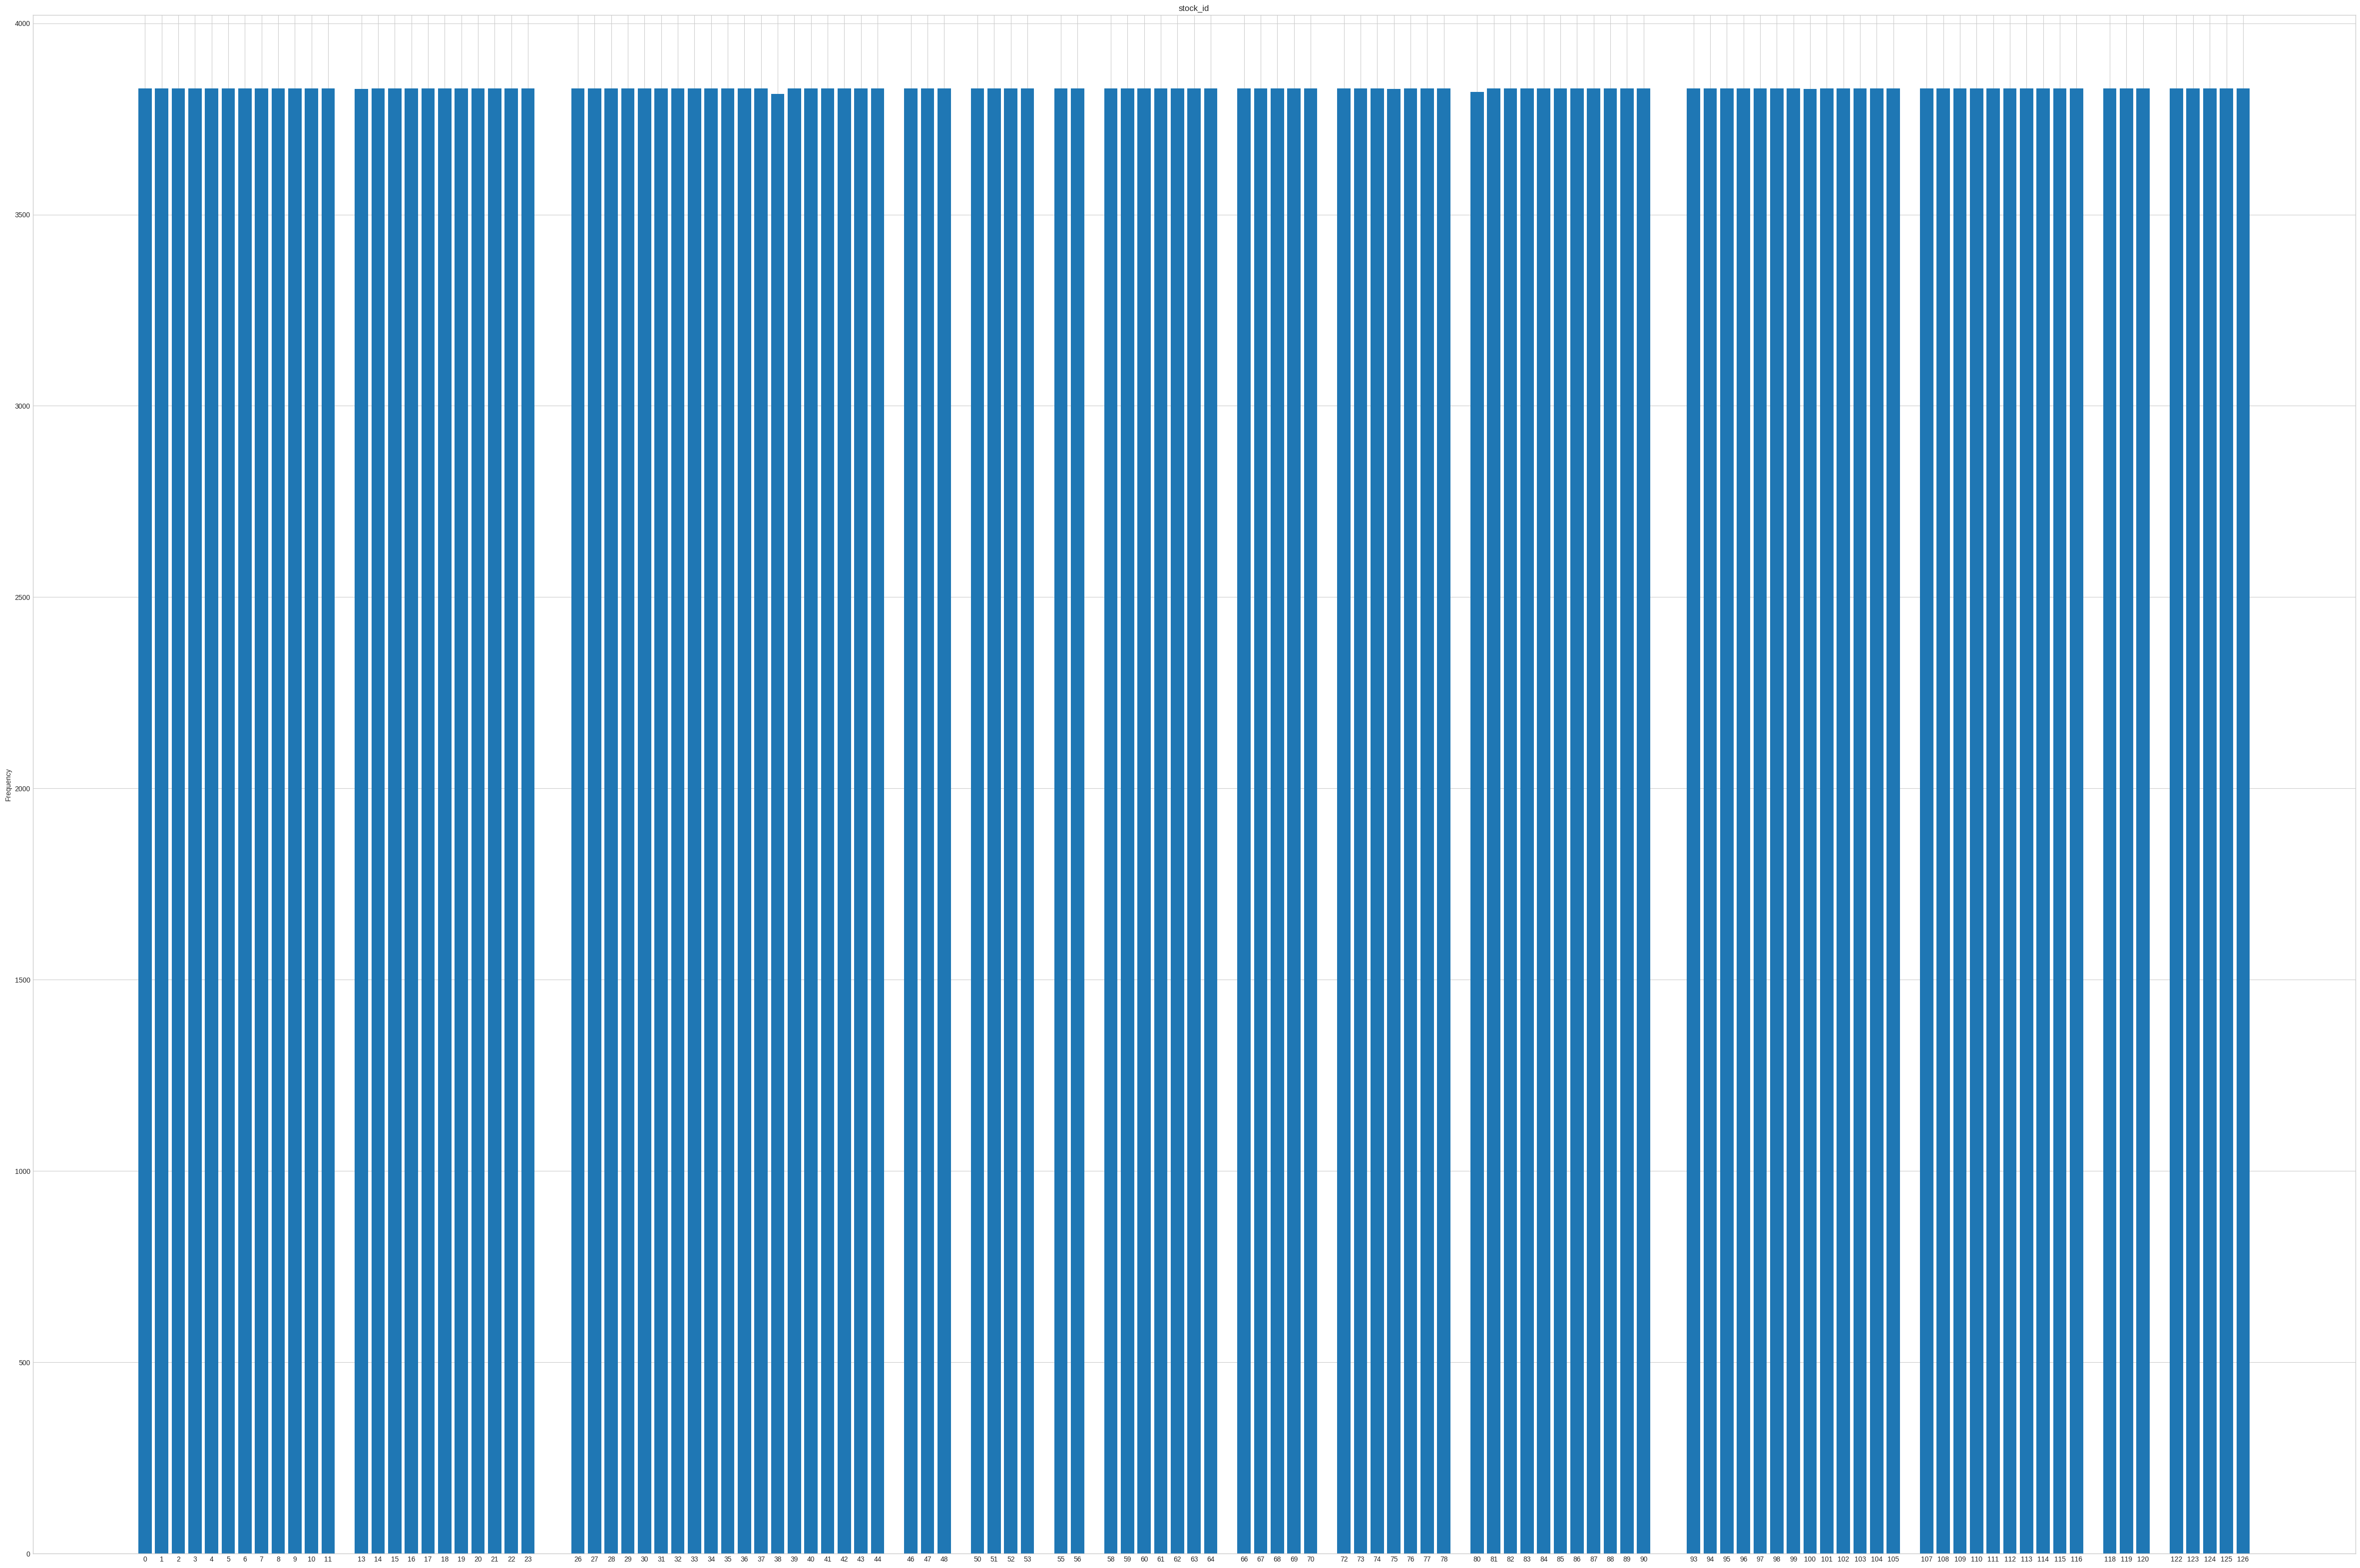

stock_id: 
 stock_id
0      3830
81     3830
94     3830
93     3830
90     3830
       ... 
13     3829
75     3829
100    3829
80     3820
38     3815
Name: count, Length: 112, dtype: int64


In [ ]:
category1 = ["stock_id"]
for c in category1:
    bar_plot(c)

In [ ]:
category2 = ["target","stock_id","time_id"]
for c in category2:
    print("{} \n".format(train_df[c].value_counts()))

target
0.003963    4
0.002682    4
0.003477    4
0.001748    4
0.002101    4
           ..
0.006612    1
0.003643    1
0.002426    1
0.006695    1
0.002090    1
Name: count, Length: 414287, dtype: int64 

stock_id
0      3830
81     3830
94     3830
93     3830
90     3830
       ... 
13     3829
75     3829
100    3829
80     3820
38     3815
Name: count, Length: 112, dtype: int64 

time_id
5        112
21148    112
21053    112
21074    112
21079    112
        ... 
14995    111
7564     111
8353     111
24161    111
23873    111
Name: count, Length: 3830, dtype: int64 



<a id = "5"></a><br>
### Numerical Variable

In [ ]:
def plot_hist(variable):
    plt.figure(figsize = (9,3))
    plt.hist(train_df[variable], bins = 50)
    plt.xlabel(variable)
    plt.ylabel("Frequency")
    plt.title("{} distrinübution with hist".format(variable))
    plt.show()

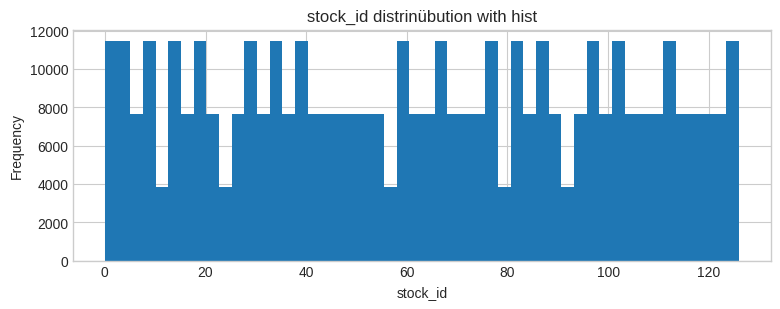

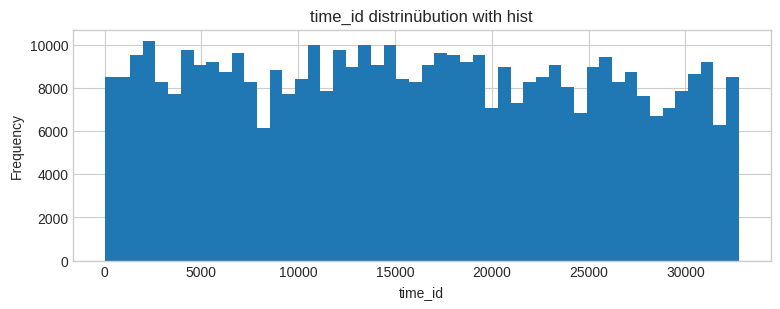

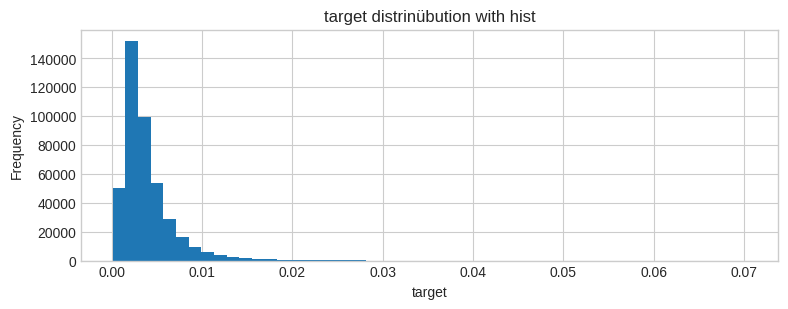

In [ ]:
numericVar = ["stock_id", "time_id", "target"]
for n in numericVar:
    plot_hist(n)

<a id = "6"></a><br>
# Basic Data Analysis
* stock_id - target
* time_id - target

In [ ]:
train_df[["time_id","target"]].groupby(["time_id"], as_index = False).mean().sort_values(by="target",ascending = False)

,time_id,target
2394,19725,0.024121
390,3138,0.018196
3537,30128,0.017968
645,5303,0.017514
212,1813,0.017422
...,...,...
1408,11886,0.001282
3659,31214,0.001275
987,8196,0.001248
2099,17387,0.001240


In [ ]:
train_df[["stock_id","target"]].groupby(["stock_id"], as_index = False).mean().sort_values(by="target",ascending = False)

,stock_id,target
17,18,0.008707
70,80,0.007424
6,6,0.006923
66,75,0.006907
24,27,0.006738
...,...,...
38,41,0.002109
110,125,0.002016
42,46,0.001941
26,29,0.001836


<a id = "7"></a><br>
# Outlier Detection

In [ ]:
def detect_outliers(df,features):
    outlier_indices = []

    for c in features:
        # 1st quartile
        Q1 = np.percentile(df[c],25)
        # 3nd quartile
        Q3 = np.percentile(df[c],75)
        # IQR
        IQR = Q3 - Q1
        # Outlier step
        outlier_step = IQR * 1.5
        # detect outlier and their indices
        outlier_list_col = df[(df[c] < Q1 - outlier_step) | (df[c] > Q3 + outlier_step)].index
        # store indices
        outlier_indices.extend(outlier_list_col)

    outlier_indices = Counter(outlier_indices)
    multiple_outliers = list(i for i, v in outlier_indices.items() if v > 2)

    return multiple_outliers

In [ ]:
train_df.loc[detect_outliers(train_df,["time_id","stock_id","target"])]

,stock_id,time_id,target


In [ ]:
# drop outliers
train_df = train_df.drop(detect_outliers(train_df,["time_id","stock_id","target"]), axis = 0).reset_index(drop = True)

<a id = "8"></a><br>
# Missing Value
* Find Missing Value
* Fill Missing Value

In [ ]:
train_df_len = len(train_df)
train_df = pd.concat([train_df,test_df],axis = 0).reset_index(drop = True)

<a id = "9"></a><br>
## Find Missing Value

In [ ]:
train_df.columns[train_df.isnull().any()]

Index(['target', 'row_id'], dtype='object')

In [ ]:
train_df.isnull().sum()

,0
stock_id,0
time_id,0
target,3
row_id,428932


<a id = "10"></a><br>
## Fill Missing Value
* target has 3 missing values

In [ ]:
train_df[train_df["target"].isnull()]

,stock_id,time_id,target,row_id
428932,0,4,NaN,0-4
428933,0,32,NaN,0-32
428934,0,34,NaN,0-34


<a id = 11></a><br>
# Visualization

<a id = 12></a><br>
## Correlation Between time_id -- stock_id -- target

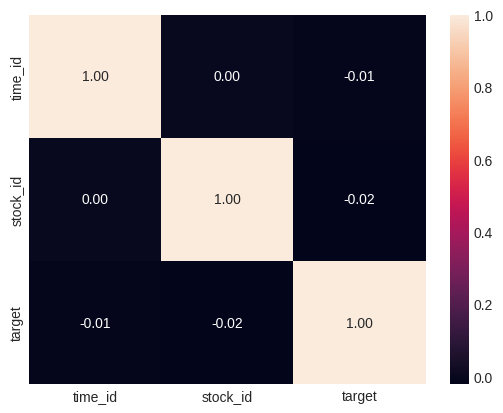

In [ ]:
list1 = ["time_id","stock_id","target"]
sns.heatmap(train_df[list1].corr(), annot = True, fmt = ".2f")
plt.show()

stock_id feature seems to have correlation with target feature(-0.02)

<a id = 13></a><br>
## stock_id -- target

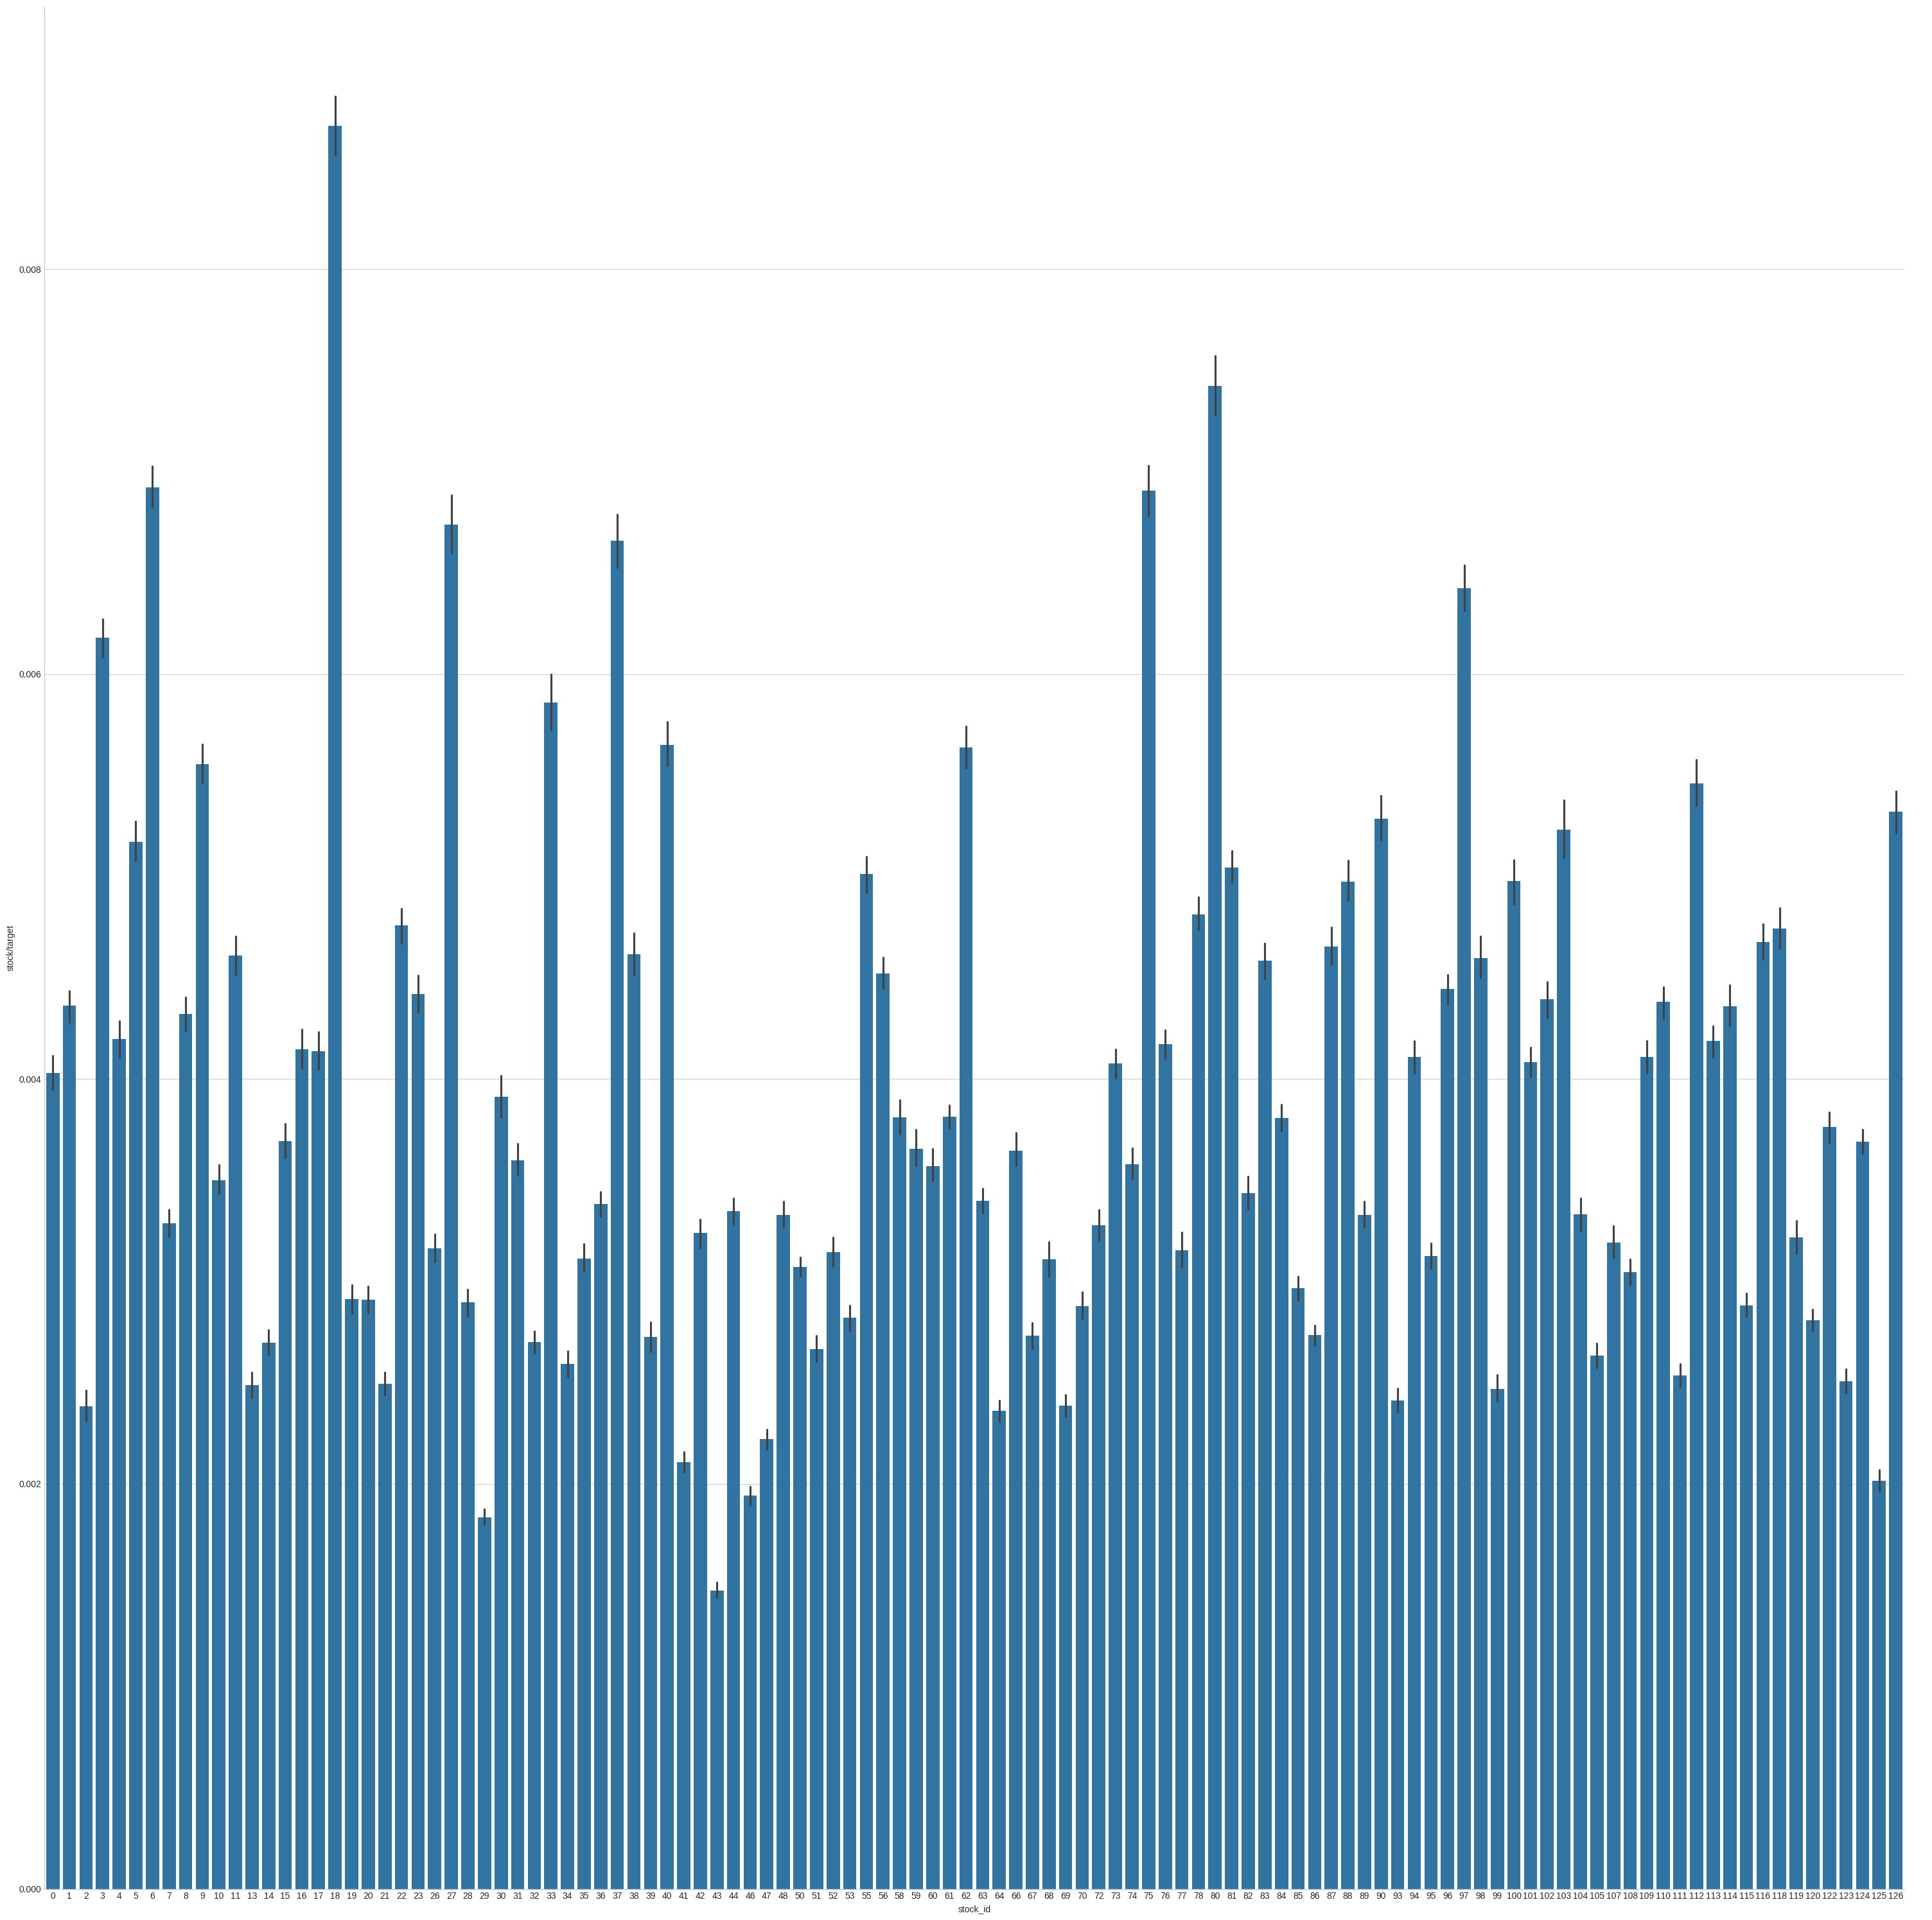

In [ ]:
g = sns.catplot(x="stock_id", y="target", data=train_df, kind="bar", height=30) # Use catplot instead of factorplot
g.set_ylabels("stock/target")
plt.show()

* when stock_id == 28 or 43 or 125, stock/target rate has a less ratio among others
* stock/target rate has more stock_id unit that includes the most ones in the first half